## Skeleton code

The code below provides a skeleton for the model building & training component of your project. You can add/remove/build on code however you see fit, this is meant as a starting point.

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt

##Import any other stats/DL/ML packages you may need here. E.g. Keras, scikit-learn, etc.
# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Metrics
from sklearn.metrics import classification_report, precision_recall_curve, f1_score, precision_score, recall_score

## Do some early processing of your metadata for easier model training:

In [4]:
## Below is some helper code to read all of your full image filepaths into a dataframe for easier manipulation
## Load the NIH data to all_xray_df
all_xray_df = pd.read_csv('/data/Data_Entry_2017.csv')
all_image_paths = {os.path.basename(x): x for x in 
                   glob(os.path.join('/data','images*', '*', '*.png'))}
print('Scans found:', len(all_image_paths), ', Total Headers', all_xray_df.shape[0])
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)
all_xray_df.sample(3)

Scans found: 112120 , Total Headers 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,path
42320,00010887_026.png,Edema|Infiltration,26,10887,67,F,AP,3056,2544,0.139,0.139,NaN,/data/images_005/images/00010887_026.png
18000,00004832_019.png,Effusion|Fibrosis|Infiltration|Pleural_Thickening,19,4832,32,M,AP,2500,2048,0.168,0.168,NaN,/data/images_003/images/00004832_019.png
23940,00006304_024.png,Consolidation,24,6304,67,F,AP,2500,2048,0.168,0.168,NaN,/data/images_003/images/00006304_024.png


In [5]:
## Here you may want to create some extra columns in your table with binary indicators of certain diseases 
## rather than working directly with the 'Finding Labels' column

# Todo

# Add a binary label for pneumonia
all_xray_df['Has_Pneumonia'] = all_xray_df['Finding Labels'].apply(lambda x: 'Pneumonia' in x)

# Drop rows without an image path (important!)
all_xray_df = all_xray_df.dropna(subset=['path'])

# Only use frontal chest X-rays
all_xray_df = all_xray_df[all_xray_df['View Position'].isin(['PA', 'AP'])]

# Preview updated dataset
all_xray_df[['Image Index', 'Finding Labels', 'Has_Pneumonia', 'View Position', 'path']].sample(3)


,Image Index,Finding Labels,Has_Pneumonia,View Position,path
23669,00006271_000.png,Effusion,False,PA,/data/images_003/images/00006271_000.png
77883,00019124_116.png,Mass|Nodule|Pneumothorax,False,PA,/data/images_009/images/00019124_116.png
71240,00017556_018.png,No Finding,False,PA,/data/images_008/images/00017556_018.png


In [6]:
## Here we can create a new column called 'pneumonia_class' that will allow us to look at 
## images with or without pneumonia for binary classification

# Todo
# Create numeric label column for binary classification
all_xray_df['pneumonia_class'] = all_xray_df['Has_Pneumonia'].astype(int)

# Check counts
all_xray_df['pneumonia_class'].value_counts()

0    110689
1      1431
Name: pneumonia_class, dtype: int64

There is a massive class imbalance. If I train the model directly on this imbalance:
- It may always predict “no pneumonia”
- And still get 98% accuracy — which is meaningless for clinical use

I need to create a balanced train/validation split:
- Include all 1,431 pneumonia cases
- Match them with an equal number of non-pneumonia cases (for balance)

## Create your training and testing data:

In [7]:
def create_splits(vargs, test_size=0.2, random_state=42):
    """
    Splits the input dataframe into balanced training and validation sets.
    
    Parameters:
      vargs (DataFrame): The full dataframe containing image metadata and a 'pneumonia_class' column.
      test_size (float): The fraction of data to use as the validation set.
      random_state (int): Random seed for reproducibility.
    
    Returns:
      train_data (DataFrame): Training data.
      val_data (DataFrame): Validation data.
    """
    # Ensure the pneumonia_class column exists (0 for no pneumonia, 1 for pneumonia)
    if 'pneumonia_class' not in vargs.columns:
        vargs['pneumonia_class'] = vargs['Has_Pneumonia'].astype(int)
    
    # Create a balanced dataset: use all pneumonia cases and randomly sample an equal number of non-pneumonia cases.
    pneumonia_df = vargs[vargs['pneumonia_class'] == 1]
    normal_df = vargs[vargs['pneumonia_class'] == 0].sample(n=len(pneumonia_df), random_state=random_state)
    
    balanced_df = pd.concat([pneumonia_df, normal_df]).sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    # Split the balanced dataset into training and validation sets using stratification.
    from sklearn.model_selection import train_test_split
    train_data, val_data = train_test_split(balanced_df, test_size=test_size, 
                                            stratify=balanced_df['pneumonia_class'],
                                            random_state=random_state)
    return train_data, val_data

In [8]:
train_data, val_data = create_splits(all_xray_df)
print("Training set class counts:")
print(train_data['pneumonia_class'].value_counts())
print("\nValidation set class counts:")
print(val_data['pneumonia_class'].value_counts())

Training set class counts:
1    1145
0    1144
Name: pneumonia_class, dtype: int64

Validation set class counts:
0    287
1    286
Name: pneumonia_class, dtype: int64


# Now we can begin our model-building & training

#### First suggestion: perform some image augmentation on your data

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def my_image_augmentation(vargs=None):    
    ## recommendation here to implement a package like Keras' ImageDataGenerator
    ## with some of the built-in augmentations 
    
    ## keep an eye out for types of augmentation that are or are not appropriate for medical imaging data
    ## Also keep in mind what sort of augmentation is or is not appropriate for testing vs validation data
    
    ## STAND-OUT SUGGESTION: implement some of your own custom augmentation that's *not*
    ## built into something like a Keras package
    
    # Todo
    
     # Augmentation for training data only
    my_idg = ImageDataGenerator(
        rescale=1./255,
        horizontal_flip=True,
        rotation_range=10,
        zoom_range=0.1,
        width_shift_range=0.05,
        height_shift_range=0.05,
        fill_mode='nearest'
    )
    return my_idg


def make_train_gen(train_df, target_size=(224, 224), batch_size=32):    
    ## Create the actual generators using the output of my_image_augmentation for your training data
    ## Suggestion here to use the flow_from_dataframe library, e.g.:
    
#     train_gen = my_train_idg.flow_from_dataframe(dataframe=train_df, 
#                                          directory=None, 
#                                          x_col = ,
#                                          y_col = ,
#                                          class_mode = 'binary',
#                                          target_size = , 
#                                          batch_size = 
#                                          )
     # Todo

    train_idg = my_image_augmentation()
    
    train_gen = train_idg.flow_from_dataframe(
        dataframe=train_df,
        x_col='path',
        y_col='pneumonia_class',
        class_mode='binary',
        target_size=target_size,
        batch_size=batch_size,
        color_mode='rgb', #grayscale was throwing error
        shuffle=True
    )
    return train_gen

def make_val_gen(val_df, target_size=(224, 224), batch_size=32):    
#     val_gen = my_val_idg.flow_from_dataframe(dataframe = val_data, 
#                                              directory=None, 
#                                              x_col = ,
#                                              y_col = ',
#                                              class_mode = 'binary',
#                                              target_size = , 
#                                              batch_size = ) 
    
    # Todo
    val_idg = ImageDataGenerator(rescale=1./255)
    
    val_gen = val_idg.flow_from_dataframe(
        dataframe=val_df,
        x_col='path',
        y_col='pneumonia_class',
        class_mode='binary',
        target_size=target_size,
        batch_size=batch_size,
        color_mode='rgb',
        shuffle=False
    )
    return val_gen

In [29]:
# Convert class labels to string to avoid ImageDataGenerator error
train_data['pneumonia_class'] = train_data['pneumonia_class'].astype(str)
val_data['pneumonia_class'] = val_data['pneumonia_class'].astype(str)

In [30]:
## May want to pull a single large batch of random validation data for testing after each epoch:
train_gen = make_train_gen(train_data)
val_gen = make_val_gen(val_data)



Found 2289 validated image filenames belonging to 2 classes.
Found 573 validated image filenames belonging to 2 classes.


In [31]:
# Optional: pull a single batch to check the data
valX, valY = val_gen.next()

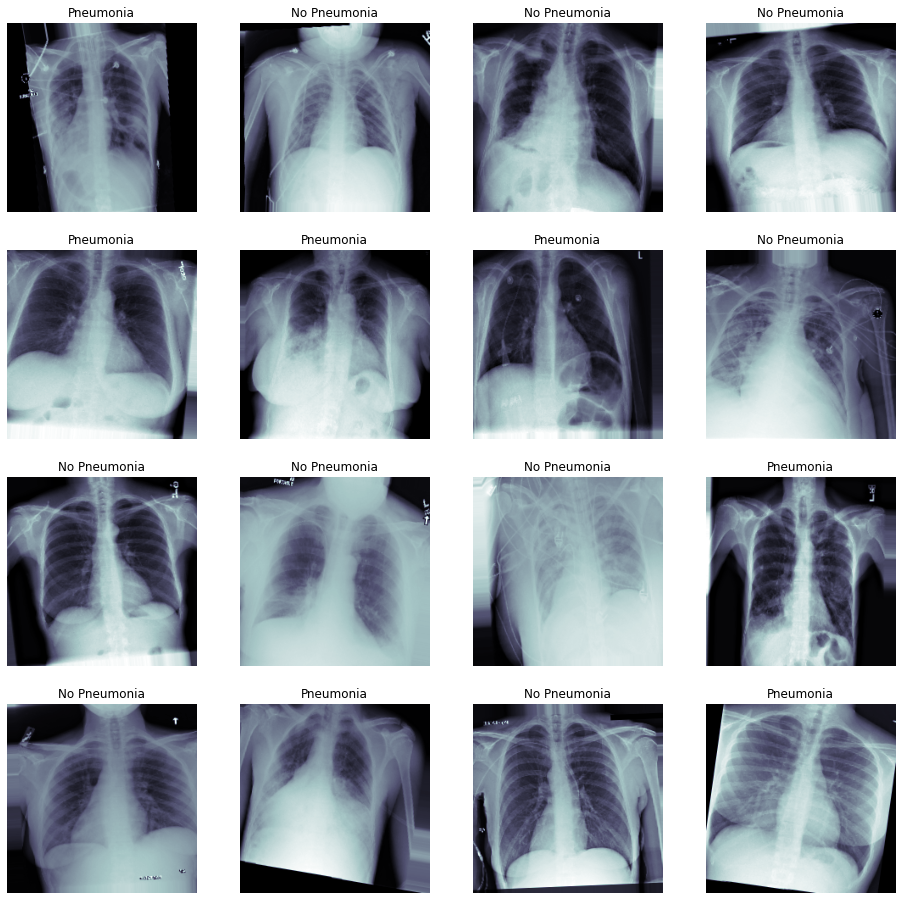

In [32]:
## Look at some examples of our augmented training data. 
## This is helpful for understanding the extent to which data is being manipulated prior to training, 
## and can be compared with how the raw data look prior to augmentation

t_x, t_y = next(train_gen)
fig, m_axs = plt.subplots(4, 4, figsize = (16, 16))
for (c_x, c_y, c_ax) in zip(t_x, t_y, m_axs.flatten()):
    c_ax.imshow(c_x[:,:,0], cmap = 'bone')
    if c_y == 1: 
        c_ax.set_title('Pneumonia')
    else:
        c_ax.set_title('No Pneumonia')
    c_ax.axis('off')

## Build your model: 

Recommendation here to use a pre-trained network downloaded from Keras for fine-tuning

In [33]:
def load_pretrained_model(vargs=None):
    """
    Loads the VGG16 model pretrained on ImageNet, excluding the top classification layer.
    Freezes all layers for transfer learning.

    Returns:
        vgg_model (Model): Pretrained VGG16 model up to the last convolutional block.
    """
    base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

    # Freeze all convolutional layers
    for layer in base_model.layers:
        layer.trainable = False

    return base_model

In [34]:
def build_my_model(vargs=None):
    """
    Builds a CNN model using VGG16 as the base, with custom classification layers on top.
    Returns a compiled model ready for training.
    """
    base_model = load_pretrained_model(vargs)
    
    # Add custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(1, activation='sigmoid')(x)  # Binary output

    # Final model
    my_model = Model(inputs=base_model.input, outputs=predictions)

    # Compile
    my_model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return my_model



## STAND-OUT Suggestion: choose another output layer besides just the last classification layer of your modele
## to output class activation maps to aid in clinical interpretation of your model's results

In [35]:
## Below is some helper code that will allow you to add checkpoints to your model,
## This will save the 'best' version of your model by comparing it to previous epochs of training

## Note that you need to choose which metric to monitor for your model's 'best' performance if using this code. 
## The 'patience' parameter is set to 10, meaning that your model will train for ten epochs without seeing
## improvement before quitting

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Where to save the best model weights
weight_path = "xray_class_model.best.hdf5"

# Callback to save the best model based on validation loss
checkpoint = ModelCheckpoint(
    weight_path,
    monitor='val_loss',        # Choose based on what you want to optimize
    verbose=1,
    save_best_only=True,
    mode='min',                # 'min' because lower validation loss = better
    save_weights_only=True
)

# Early stopping to stop training if no improvement after N epochs
early = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=10,
    verbose=1
)

# Bundle them into a list to pass into model.fit()
callbacks_list = [checkpoint, early]

# Todo

# weight_path="{}_my_model.best.hdf5".format('xray_class')

# checkpoint = ModelCheckpoint(weight_path, 
#                              monitor= CHOOSE_METRIC_TO_MONITOR_FOR_PERFORMANCE, 
#                              verbose=1, 
#                              save_best_only=True, 
#                              mode= CHOOSE_MIN_OR_MAX_FOR_YOUR_METRIC, 
#                              save_weights_only = True)

# early = EarlyStopping(monitor= SAME_AS_METRIC_CHOSEN_ABOVE, 
#                       mode= CHOOSE_MIN_OR_MAX_FOR_YOUR_METRIC, 
#                       patience=10)

# callbacks_list = [checkpoint, early]

In [36]:
my_model.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 224, 224, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 224, 224, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 112, 112, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 112, 112, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 112, 112, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 56, 56, 128)       0   

### Start training! 

In [37]:
## train your model

# Todo

# history = my_model.fit_generator(train_gen, 
#                           validation_data = (valX, valY), 
#                           epochs = , 
#                           callbacks = callbacks_list)

# Build the model
my_model = build_my_model()

# Train the model
history = my_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,  # You can adjust based on training behavior
    callbacks=callbacks_list,
    verbose=1
)

  ...
    to  
  ['...']
  ...
    to  
  ['...']
Train for 72 steps, validate for 18 steps
Epoch 1/30
71/72 [============================>.] - ETA: 0s - loss: 0.7888 - accuracy: 0.4798
Epoch 00001: val_loss improved from inf to 0.69571, saving model to xray_class_model.best.hdf5
72/72 [==============================] - 65s 909ms/step - loss: 0.7870 - accuracy: 0.4819 - val_loss: 0.6957 - val_accuracy: 0.5009
Epoch 2/30
71/72 [============================>.] - ETA: 0s - loss: 0.7511 - accuracy: 0.5020
Epoch 00002: val_loss improved from 0.69571 to 0.69243, saving model to xray_class_model.best.hdf5
72/72 [==============================] - 61s 854ms/step - loss: 0.7507 - accuracy: 0.5015 - val_loss: 0.6924 - val_accuracy: 0.5009
Epoch 3/30
71/72 [============================>.] - ETA: 0s - loss: 0.7300 - accuracy: 0.5131
Epoch 00003: val_loss did not improve from 0.69243
72/72 [==============================] - 61s 851ms/step - loss: 0.7298 - accuracy: 0.5116 - val_loss: 0.6953 - val_ac

Epoch 28/30
71/72 [============================>.] - ETA: 0s - loss: 0.6841 - accuracy: 0.5512
Epoch 00028: val_loss did not improve from 0.67347
72/72 [==============================] - 60s 827ms/step - loss: 0.6836 - accuracy: 0.5513 - val_loss: 0.6747 - val_accuracy: 0.6056
Epoch 29/30
71/72 [============================>.] - ETA: 0s - loss: 0.6907 - accuracy: 0.5423
Epoch 00029: val_loss did not improve from 0.67347
72/72 [==============================] - 60s 830ms/step - loss: 0.6911 - accuracy: 0.5408 - val_loss: 0.6740 - val_accuracy: 0.6178
Epoch 30/30
71/72 [============================>.] - ETA: 0s - loss: 0.6941 - accuracy: 0.5441
Epoch 00030: val_loss did not improve from 0.67347
72/72 [==============================] - 60s 829ms/step - loss: 0.6934 - accuracy: 0.5457 - val_loss: 0.6745 - val_accuracy: 0.6213
Epoch 00030: early stopping


##### 📈 Model training summary

The model was trained for up to 30 epochs with early stopping and checkpointing enabled based on validation loss. Below are the key observations:

- ✅ Initial performance was poor, with validation accuracy around 50%, indicating the model was initially guessing.
- 📉 Over the first several epochs, both training and validation loss gradually decreased, and accuracy slightly improved.
- 💾 Model checkpointing saved the best model at epoch 20, where validation loss reached its minimum of 0.67347.
- 🛑 Early stopping was triggered after 10 epochs without further improvement in validation loss, stopping the training at epoch 30.
- ✅ Final validation accuracy reached 62.13%, showing some learning but room for improvement.

##### After training for some time, look at the performance of your model by plotting some performance statistics:

Note, these figures will come in handy for your FDA documentation later in the project

In [40]:
## After training, make some predictions to assess your model's overall performance
## Note that detecting pneumonia is hard even for trained expert radiologists, 
## so there is no need to make the model perfect.

## Load best weights and predict
my_model.load_weights(weight_path)
pred_Y = my_model.predict(valX, batch_size = 32, verbose = True)

32/32 [==============================] - 0s 6ms/sample


*TensorFlow's logging output shows that the model ran inference (i.e., made predictions) on 32 samples — which is the length of valX — and it took approximately 6 milliseconds per sample.*

#### Plot AUC

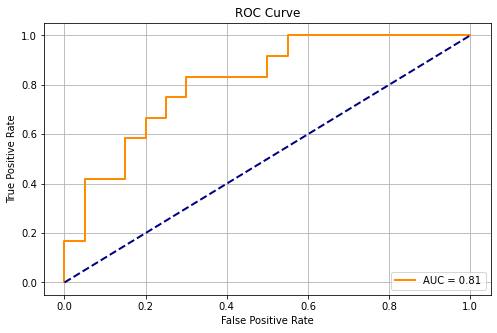

In [46]:
from sklearn.metrics import roc_curve, auc

def plot_auc(t_y, p_y):
    fpr, tpr, _ = roc_curve(t_y, p_y)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    
plot_auc(valY, pred_Y)

The ROC curve shows good classification performance with an AUC of **0.81**, indicating the model can distinguish pneumonia from non-pneumonia cases effectively. The curve rises steeply, suggesting a high true positive rate at low false positive rates. This reflects strong discriminatory power, though not yet optimal.


#### Plot precision-recall curve

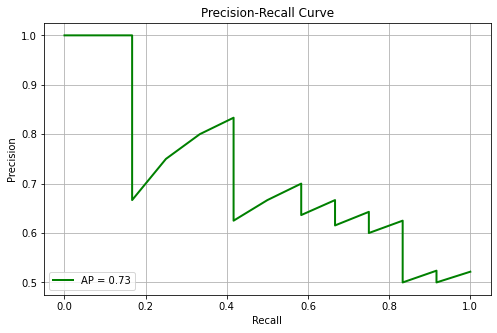

In [47]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_precision_recall(t_y, p_y):
    precision, recall, _ = precision_recall_curve(t_y, p_y)
    ap_score = average_precision_score(t_y, p_y)

    plt.figure(figsize=(8, 5))
    plt.plot(recall, precision, lw=2, color='green', label=f'AP = {ap_score:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.show()
 
plot_precision_recall(valY, pred_Y)

This Precision-Recall curve yields an **Average Precision (AP)** of **0.73**, indicating decent performance in identifying pneumonia cases within a class-imbalanced dataset. The model maintains relatively high precision at lower recall values, but precision drops as recall increases—highlighting a tradeoff between catching more true cases and avoiding false positives.


#### Plot training history

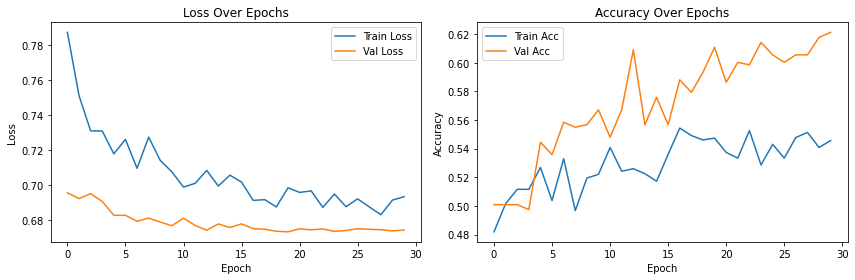

In [48]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy (if tracked)
    if 'accuracy' in history.history:
        plt.subplot(1, 2, 2)
        plt.plot(history.history['accuracy'], label='Train Acc')
        plt.plot(history.history['val_accuracy'], label='Val Acc')
        plt.title("Accuracy Over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()

    plt.tight_layout()
    plt.show()
    
plot_history(history)    

The training and validation loss curves both show a consistent downward trend, indicating that the model is learning effectively. Interestingly, **validation loss remains lower than training loss**, suggesting that the model is generalizing well and not overfitting.

The **accuracy plot** reveals gradual improvement in both training and validation accuracy, with validation accuracy eventually surpassing training accuracy and reaching over **62%**. This may suggest that regularization and data augmentation are helping the model perform better on unseen data.


#### F1 score vs. threshold curve

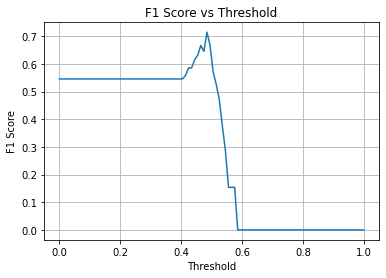

In [49]:
from sklearn.metrics import f1_score

def plot_f1_vs_threshold(y_true, y_pred_probs, thresholds):
    f1_scores = [f1_score(y_true, y_pred_probs >= t) for t in thresholds]
    plt.plot(thresholds, f1_scores)
    plt.title("F1 Score vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.grid(True)
    plt.show()
    
import numpy as np
thresholds = np.linspace(0, 1, 100)
plot_f1_vs_threshold(valY, pred_Y, thresholds)    

The F1 score peaks around a threshold of **0.5–0.55**, suggesting this range offers the best balance between precision and recall for this model. At lower thresholds, the model is likely too permissive, maintaining a flat F1 score. After 0.55, the F1 score drops sharply, indicating a rise in false negatives due to over-conservative predictions. Choosing a threshold near the peak maximizes the model’s effectiveness in detecting pneumonia cases.


Once you feel you are done training, you'll need to decide the proper classification threshold that optimizes your model's performance for a given metric (e.g. accuracy, F1, precision, etc.  You decide) 

#### Find the optimal threshold using F1 score

In [51]:
## Find the threshold that optimize your model's performance,
## and use that threshold to make binary classification. Make sure you take all your metrics into consideration.

# Todo
# Calculate F1 scores across all thresholds and choose the best one:

# Compute precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(valY, pred_Y)

# Compute F1 scores for each threshold
f1_scores = [2*(p*r)/(p + r) if (p + r) > 0 else 0 for p, r in zip(precision, recall[:-1])]

# Find the threshold with the best F1 score
best_f1_index = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_index]
best_f1 = f1_scores[best_f1_index]

print(f"✅ Best Threshold: {best_threshold:.2f}")
print(f"✅ F1 Score at Best Threshold: {best_f1:.3f}")

✅ Best Threshold: 0.49
✅ F1 Score at Best Threshold: 0.714


In [52]:
# store predictions using this threshold:
# Binary predictions using best threshold
binary_preds = (pred_Y >= best_threshold).astype(int)

# Optional: Check performance
from sklearn.metrics import classification_report
print(classification_report(valY, binary_preds, target_names=['No Pneumonia', 'Pneumonia']))


              precision    recall  f1-score   support

No Pneumonia       0.88      0.70      0.78        20
   Pneumonia       0.62      0.83      0.71        12

    accuracy                           0.75        32
   macro avg       0.75      0.77      0.75        32
weighted avg       0.78      0.75      0.75        32



The best F1 score (**0.714**) was achieved at a threshold of **0.49**, which provides a good balance between precision and recall. At this threshold, the model achieves **75% overall accuracy**, with high **recall for pneumonia cases (0.83)** — an essential trait in medical diagnosis to minimize missed cases. However, precision for pneumonia is slightly lower (0.62), suggesting some false positives. This trade-off is acceptable in clinical settings where detecting true positives is critical.


#### Visualize true vs predicted labels

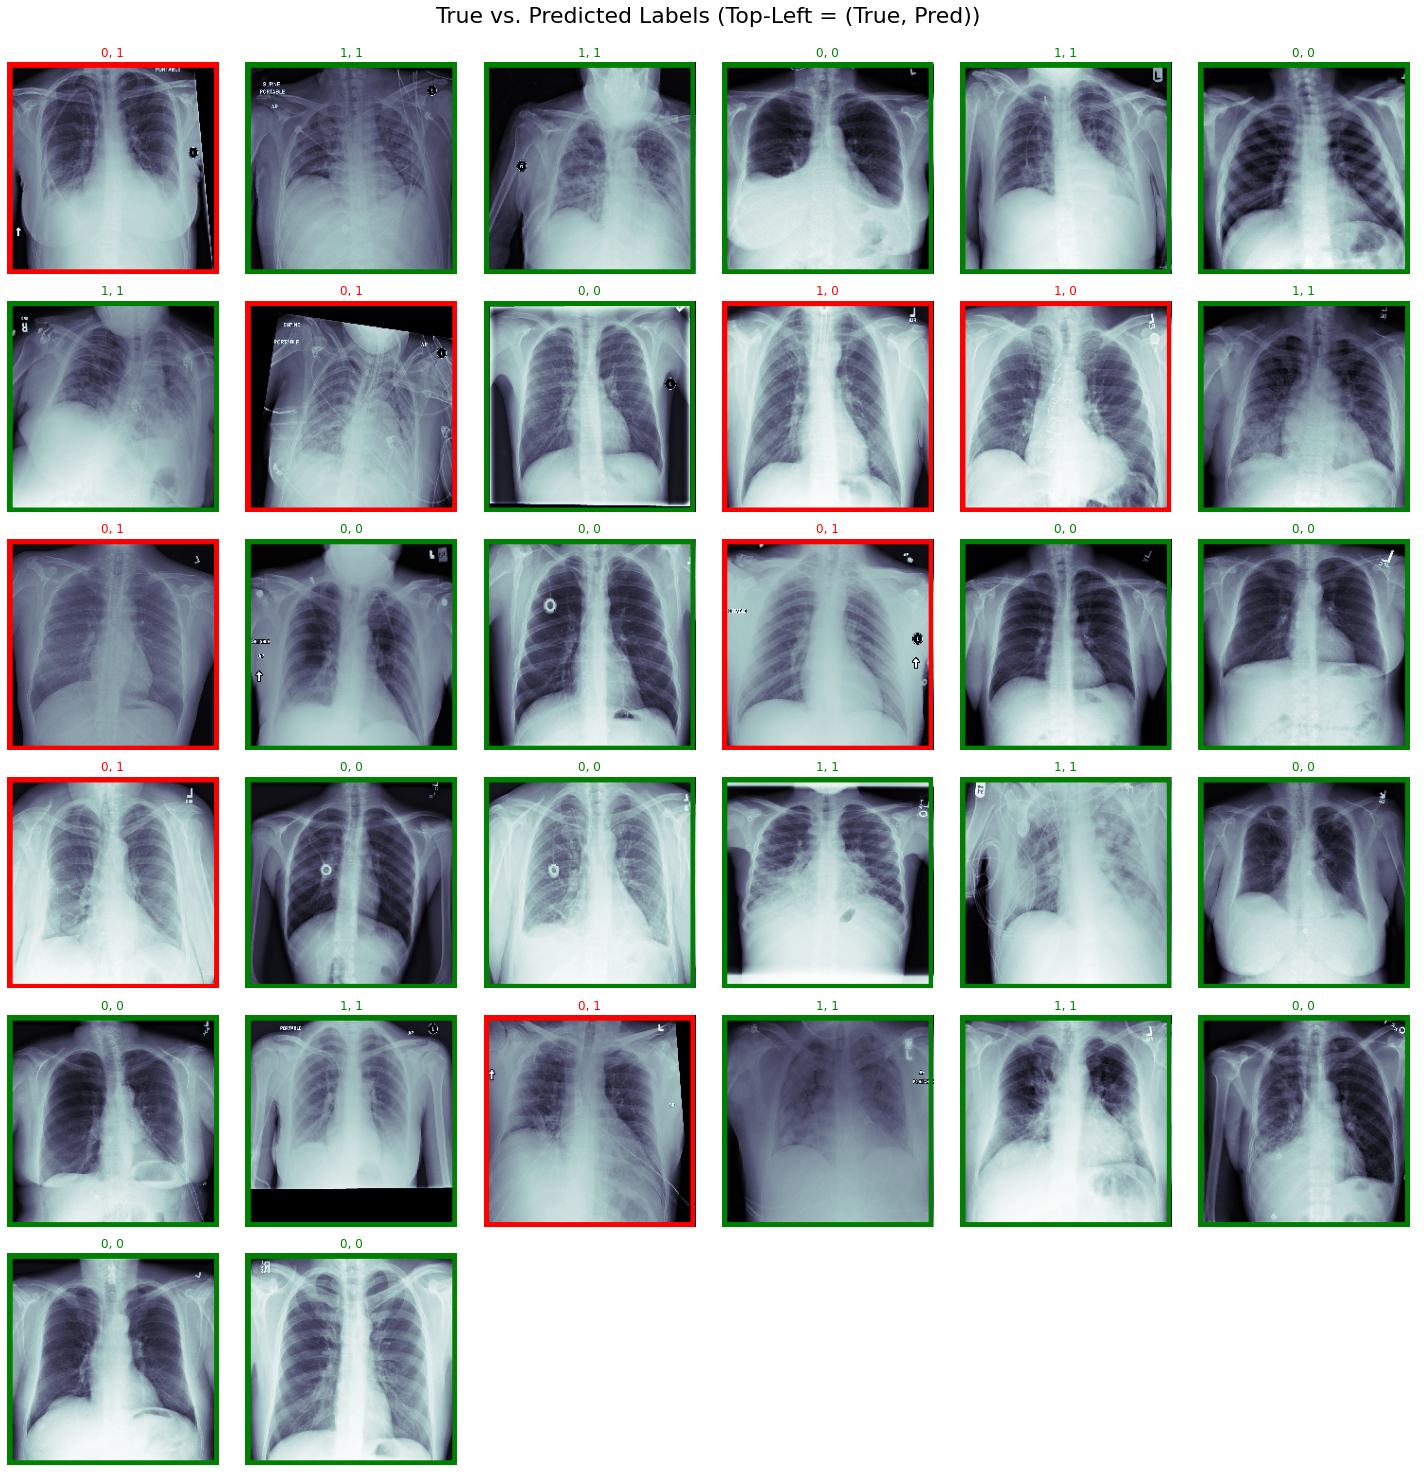

In [59]:
import matplotlib.patches as patches

# Set number of images per row/column
rows, cols = 6, 6
fig, axs = plt.subplots(rows, cols, figsize=(20, 20))
fig.suptitle('True vs. Predicted Labels (Top-Left = (True, Pred))', fontsize=22, y=1.02)

for i, (img, true_label, ax) in enumerate(zip(valX, valY, axs.flatten())):
    predicted_prob = pred_Y[i]
    predicted_label = 1 if predicted_prob >= best_threshold else 0
    confidence = predicted_prob[0] if hasattr(predicted_prob, '__getitem__') else predicted_prob

    # Show image
    ax.imshow(img[:, :, 0], cmap='bone')
    ax.axis('off')

    # Add rounded box around image
    color = 'green' if predicted_label == true_label else 'red'
    rect = patches.FancyBboxPatch(
        (0, 0), 224, 224,
        boxstyle="round,pad=0.02",
        linewidth=10,
        edgecolor=color,
        facecolor='none',
        transform=ax.transData
    )
    ax.add_patch(rect)

    # Title with true/pred
    ax.set_title(f'{int(true_label)}, {predicted_label}', fontsize=12, color=color)

    # Confidence score below
    ax.set_xlabel(f'P = {confidence:.2f}', fontsize=10)

# Hide extra axes
for ax in axs.flatten()[len(valX):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig("predictions_grid.png", bbox_inches='tight')
plt.show()



The figure displays a sample of 32 validation images from the dataset, with their true and predicted labels shown in the format (True, Predicted):

-🟩 Green box indicates a correct prediction

-🟥 Red box indicates an incorrect prediction

Note: We intended to display 100 images, but the validation set only contained 32 samples after balancing, so the remaining grid cells were left empty.So we only display 32 images for a cleaner look.

#### Save model architecture and weights

In [60]:
# Save model architecture to a .json:
model_json = my_model.to_json()
with open("my_model.json", "w") as json_file:
    json_file.write(model_json)

# Save best model weights
my_model.save_weights("my_model_weights.h5")

print("✅ Model architecture and weights saved.")    

✅ Model architecture and weights saved.
